In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.datasets import make_regression
from sklearn.utils import Bunch

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

def compute_metrics(y_true, y_pred, label):
    """Return a dict of regression metrics for a given set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Set': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def plot_actual_vs_predicted_multi(datasets):
    """Side-by-side actual vs predicted for multiple datasets.

    Parameters
    ----------
    datasets : list of (y_true, y_pred, title, color)
    """
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (y_true, y_pred, title, color) in zip(axes, datasets):
        r2 = r2_score(y_true, y_pred)
        ax.scatter(y_true, y_pred, alpha=0.5, color=color, s=25)
        mn = min(np.min(y_true), np.min(y_pred))
        mx = max(np.max(y_true), np.max(y_pred))
        ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect fit')
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{title}\nR\u00b2 = {r2:.3f}', fontweight='bold')
        ax.legend(fontsize=9)

    plt.suptitle('Actual vs Predicted — Comparing Evaluation Strategies',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_coefficients(feature_names, coefficients, title='Regression Coefficients'):
    """Horizontal bar chart of model coefficients, colored by sign."""
    coef_df = pd.DataFrame({'Feature': feature_names,
                             'Coefficient': coefficients})
    coef_df = coef_df.sort_values('Coefficient')
    colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'],
                    color=colors, edgecolor='white', height=0.6)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient Value')
    plt.title(title, fontweight='bold')

    for bar, val in zip(bars, coef_df['Coefficient']):
        plt.text(val + 2 * np.sign(val),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)
    plt.tight_layout()
    plt.show()
    return coef_df

def plot_residuals(y_true, y_pred, title='Residual Analysis'):
    """Three-panel residual diagnostic: scatter, histogram, Q-Q plot."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].scatter(y_pred, residuals, alpha=0.5, color='darkorange', s=25)
    axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Predicted', fontweight='bold')

    axes[1].hist(residuals, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Residual Value')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Residual Distribution', fontweight='bold')

    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot (should follow the line)', fontweight='bold')
    axes[2].get_lines()[1].set_color('red')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

All libraries imported successfully.


In [ ]:
X_raw, y = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=7,
    noise=20,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]

dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic regression dataset via make_regression"
)

# Now this works exactly like any sklearn dataset
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')   # Feature matrix
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Lasso(alpha=0.5)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("Model trained on training set only.")
print(f"Intercept (\u03b2\u2080): {model.intercept_:.4f}")





Model trained on training set only.
Intercept (β₀): -1.5989


                     MAE       MSE     RMSE      R2
Set                                                
Train Set (80%)  15.9423  388.9284  19.7213  0.9674
Test Set  (20%)  16.0550  416.9675  20.4198  0.9678


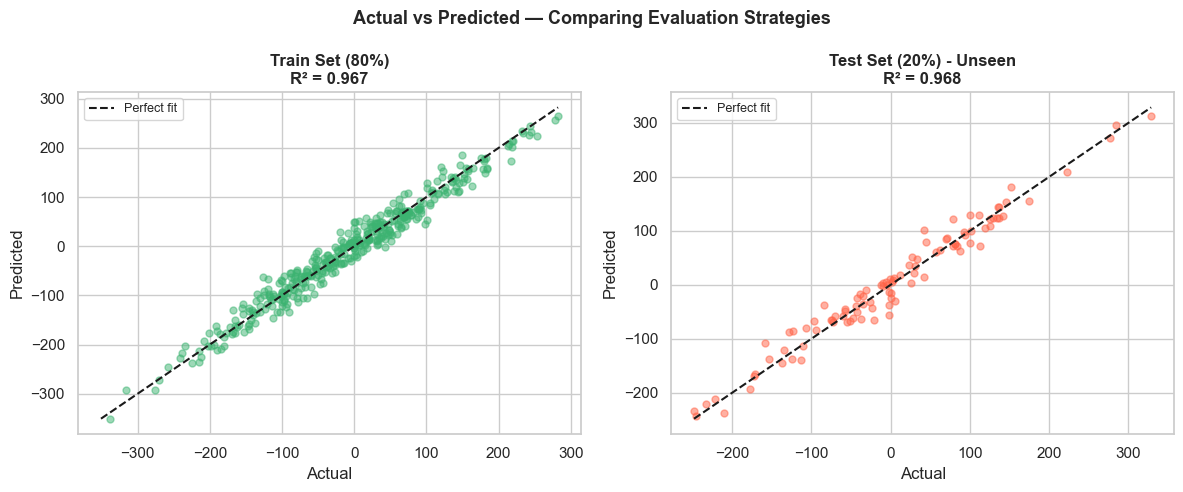

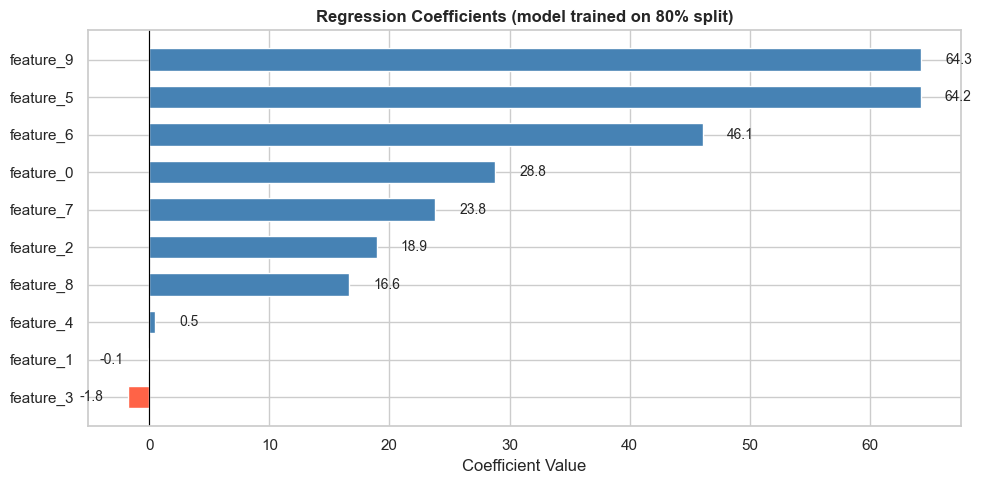


Positive drivers (increase disease progression):
  Feature  Coefficient
feature_9    64.293723
feature_5    64.238423
feature_6    46.129441
feature_0    28.819138
feature_7    23.817327
feature_2    18.924253
feature_8    16.639325
feature_4     0.469867

Negative drivers (decrease disease progression):
  Feature  Coefficient
feature_3    -1.810869
feature_1    -0.130849


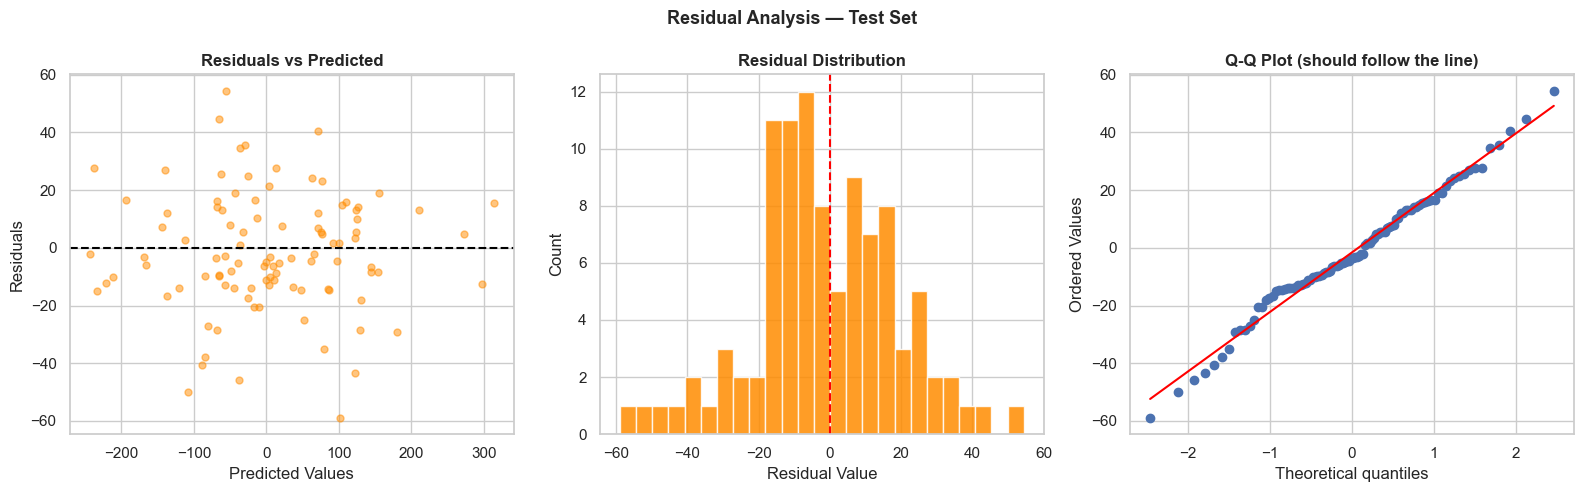

In [3]:
results = pd.DataFrame([
    compute_metrics(y_train, y_pred_train, 'Train Set (80%)'),
    compute_metrics(y_test,  y_pred_test,  'Test Set  (20%)'),
]).set_index('Set').round(4)

print(results.to_string())

plot_actual_vs_predicted_multi([
    (y_train, y_pred_train, 'Train Set (80%)',         'mediumseagreen'),
    (y_test,  y_pred_test,  'Test Set (20%) - Unseen', 'tomato'),
])

coef_df = plot_coefficients(
    feature_names=X.columns,
    coefficients=model_split.coef_,
    title='Regression Coefficients (model trained on 80% split)'
)

print("\nPositive drivers (increase disease progression):")
print(coef_df[coef_df['Coefficient'] > 0]
      .sort_values('Coefficient', ascending=False).to_string(index=False))
print("\nNegative drivers (decrease disease progression):")
print(coef_df[coef_df['Coefficient'] < 0]
      .sort_values('Coefficient').to_string(index=False))

plot_residuals(y_test, y_pred_test, title='Residual Analysis — Test Set')